In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("customer_segmentation.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [5]:
print(df.columns)

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')


In [6]:
print(df.shape)
print(df.info())

(2240, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 n

In [7]:
#check missing values and drop them
print(df.isnull().sum().sum())

24


In [8]:
#check unique values in column
df["Education"].value_counts()


Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [9]:
#data cleaning and feature engineering
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   int64         
 1   Year_Birth           2240 non-null   int64         
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   int64         
 6   Teenhome             2240 non-null   int64         
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   int64         
 9   MntWines             2240 non-null   int64         
 10  MntFruits            2240 non-null   int64         
 11  MntMeatProducts      2240 non-null   int64         
 12  MntFishProducts      2240 non-null   int64         
 13  MntSweetProducts     2240 non-nul

In [10]:
df["Age"] = 2025 - df["Year_Birth"]

In [11]:
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
spend_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df["Total_Spending"] = df[spend_cols].sum(axis=1)
df[["Total_Spending"]]

,Total_Spending
0,1617
1,27
2,776
3,53
4,422
...,...
2235,1341
2236,444
2237,1241
2238,843


In [13]:
df["Customer_Since"] = (pd.Timestamp("today") - df["Dt_Customer"]).dt.days

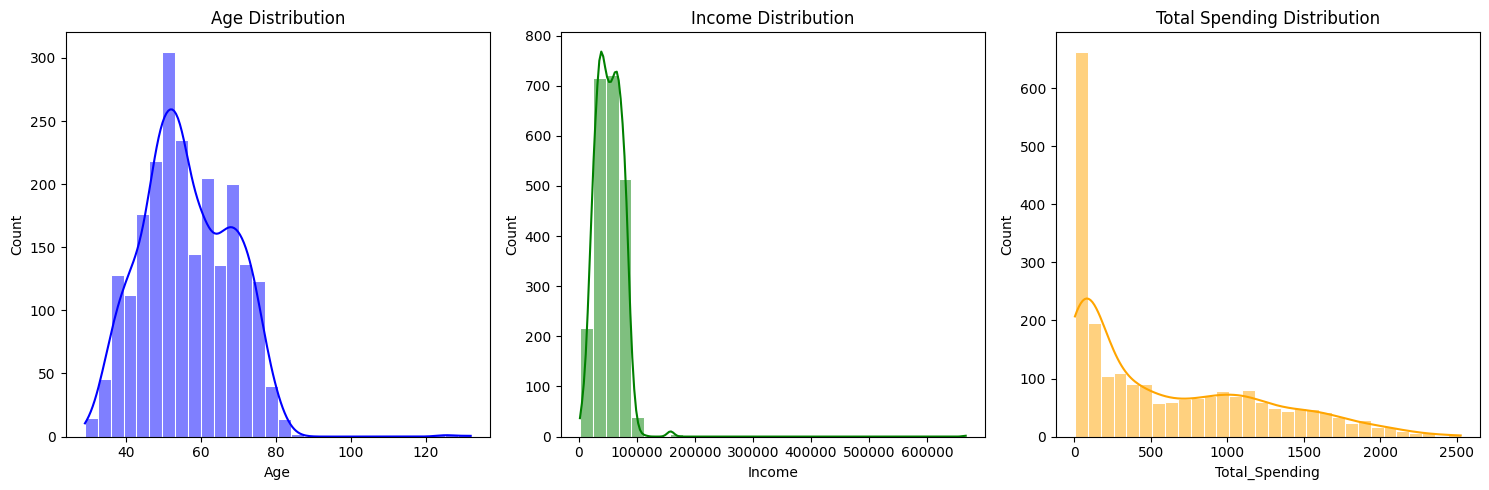

In [14]:
# Distribution plots (numerical)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))

sns.histplot(df["Age"], bins=30, color='blue', edgecolor='white', kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["Income"], bins=30, color='green', edgecolor='white', kde=True, ax=axes[1])
axes[1].set_title("Income Distribution")

sns.histplot(df["Total_Spending"], bins=30, color='orange', edgecolor='white', kde=True, ax=axes[2])
axes[2].set_title("Total Spending Distribution")

plt.tight_layout()
plt.show()

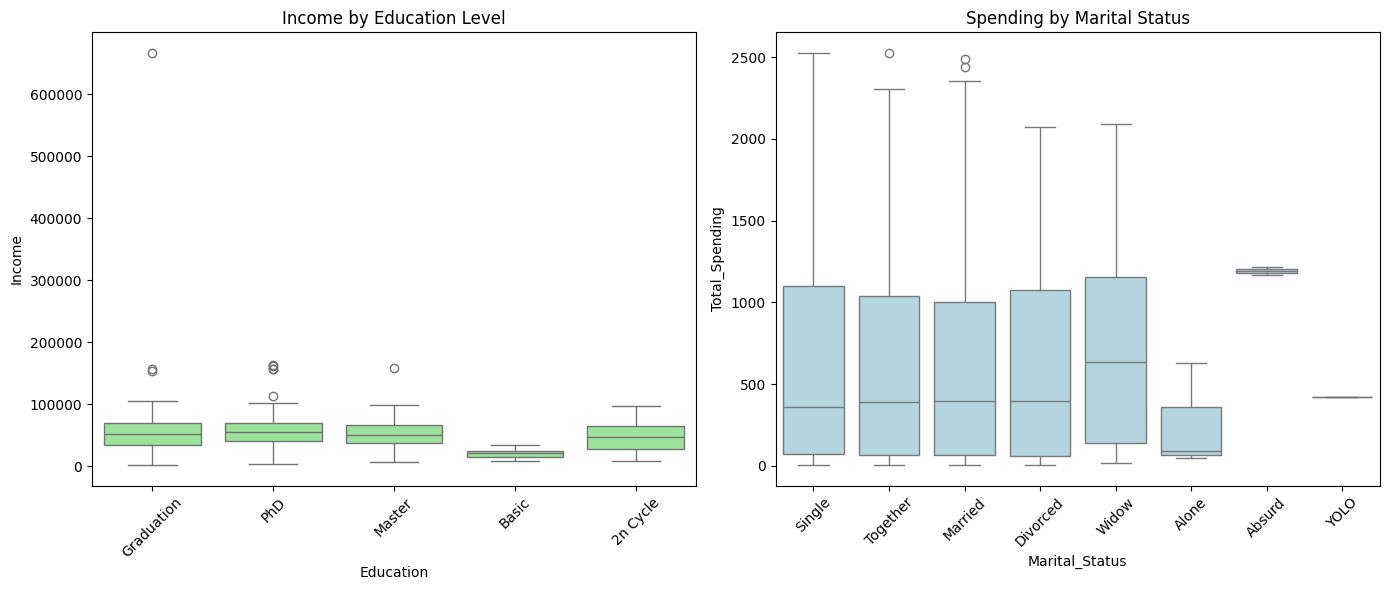

In [15]:
# Distribution plots (categorical)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

sns.boxplot(x="Education", y="Income", color="lightgreen", data=df, ax=axes[0])
axes[0].set_title("Income by Education Level")
axes[0].tick_params(axis='x', rotation=45) 

sns.boxplot(x="Marital_Status", y="Total_Spending", color="lightblue", data=df, ax=axes[1])
axes[1].set_title("Spending by Marital Status")
axes[1].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()

In [16]:
corr = df[["Income", "Age", "Recency", "Total_Spending", "NumWebPurchases", "NumStorePurchases"]].corr()
corr

,Income,Age,Recency,Total_Spending,NumWebPurchases,NumStorePurchases
Income,1.000000,0.161791,-0.003970,0.667576,0.387878,0.529362
Age,0.161791,1.000000,0.019871,0.111306,0.145040,0.128272
Recency,-0.003970,0.019871,1.000000,0.020433,-0.010726,0.000799
Total_Spending,0.667576,0.111306,0.020433,1.000000,0.519837,0.674669
NumWebPurchases,0.387878,0.145040,-0.010726,0.519837,1.000000,0.502713
NumStorePurchases,0.529362,0.128272,0.000799,0.674669,0.502713,1.000000


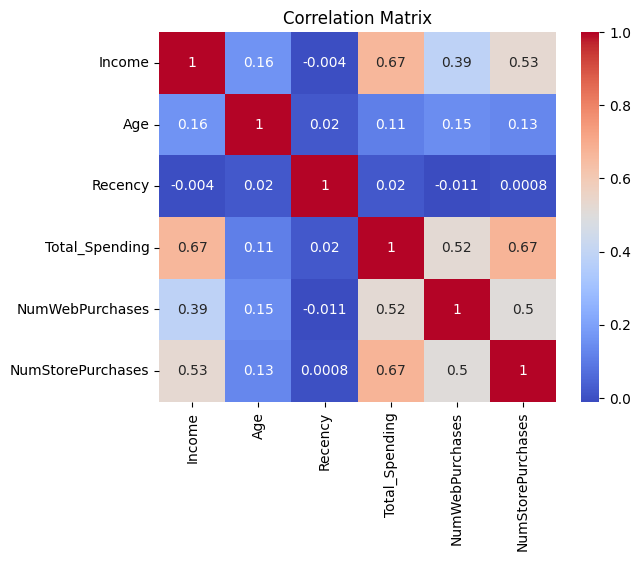

In [17]:
sns.heatmap(corr, annot= True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [18]:
pivot_income = df.pivot_table(values="Income", index="Education", columns="Marital_Status", aggfunc="mean")
pivot_income

Marital_Status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
Education,,,,,,,,
2n Cycle,NaN,NaN,49395.130435,46201.100000,53673.944444,44736.410714,51392.200000,NaN
Basic,NaN,NaN,9548.000000,21960.500000,18238.666667,21240.071429,22123.000000,NaN
Graduation,79244.0,34176.0,54526.042017,50800.258741,51322.182927,55758.480702,54976.657143,NaN
Master,65487.0,61331.0,50331.945946,53286.028986,53530.560000,52109.009804,58401.545455,NaN
PhD,NaN,35860.0,53096.615385,58138.031579,53314.614583,56041.422414,60288.083333,48432.0


Text(0.5, 1.0, 'Average Income by Education and Marital Status')

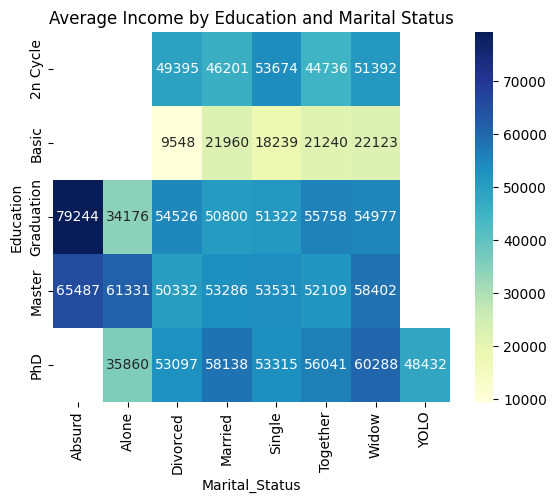

In [19]:
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Income by Education and Marital Status")

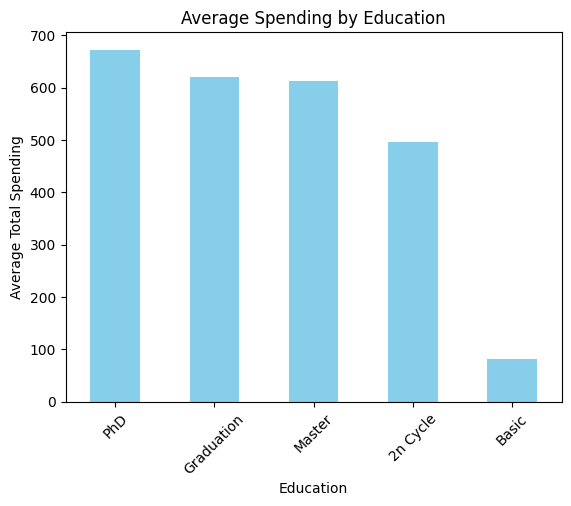

In [20]:
group1 = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)
group1.plot(kind="bar", color="skyblue")
plt.title("Average Spending by Education")
plt.ylabel("Average Total Spending")
plt.xticks(rotation=45)
plt.show()

In [21]:
df["AcceptedAny"] = df[["AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5", "Response"]].sum(axis=1)
print(df["AcceptedAny"].unique())

df["AcceptedAny"] = df["AcceptedAny"].apply(lambda x: 1 if x>0 else 0)
print(df["AcceptedAny"].unique())

[1 0 3 2 4 5]
[1 0]


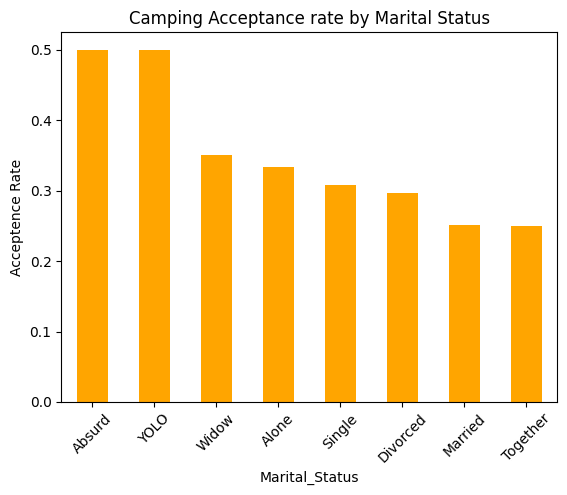

In [22]:
group2 = df.groupby("Marital_Status")["AcceptedAny"].mean().sort_values(ascending=False)
group2.plot(kind="bar", color="orange")
plt.title("Camping Acceptance rate by Marital Status")
plt.ylabel("Acceptence Rate")
plt.xticks(rotation=45)
plt.show()

AgeGroup
18-29    46658.000000
30-39    46283.028302
40-49    49224.877034
50-59    50812.913303
60-69    56200.827887
70+      58944.316294
Name: Income, dtype: float64


C:\Users\03cri\AppData\Local\Temp\ipykernel_25196\3765325403.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group3 = df.groupby("AgeGroup")["Income"].mean()


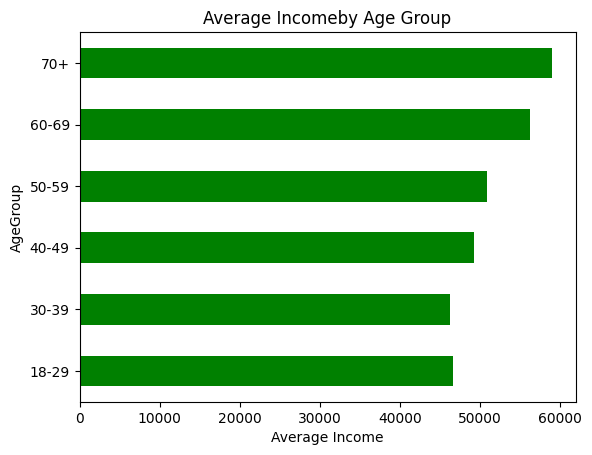

In [23]:
bins = [18, 30, 40, 50, 60, 70, 90]
labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

group3 = df.groupby("AgeGroup")["Income"].mean()
print(group3)

group3.plot(kind="barh", color="green")
plt.title("Average Incomeby Age Group")
plt.xlabel("Average Income")
plt.show()

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Children,Total_Spending,Customer_Since,AcceptedAny,AgeGroup
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,3,11,1,68,0,1617,5051,1,60-69
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,3,11,0,71,2,27,4501,0,70+
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,3,11,0,60,0,776,4700,0,50-59
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,3,11,0,41,1,53,4527,0,40-49
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,3,11,0,44,1,422,4549,0,40-49


In [25]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Age', 'Total_Children', 'Total_Spending', 'Customer_Since',
       'AcceptedAny', 'AgeGroup'],
      dtype='object')

In [26]:
features =["Age", "Income", "Total_Spending", "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth", "Recency"]

X = df[features].copy()
X

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
0,68,58138.0,1617,8,4,7,58
1,71,46344.0,27,1,2,5,38
2,60,71613.0,776,8,10,4,26
3,41,26646.0,53,2,4,6,26
4,44,58293.0,422,5,6,5,94
...,...,...,...,...,...,...,...
2235,58,61223.0,1341,9,4,5,46
2236,79,64014.0,444,8,5,7,56
2237,44,56981.0,1241,2,13,6,91
2238,69,69245.0,843,6,10,3,8


In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_scaled

array([[ 0.98534473,  0.2340627 ,  1.67941681, ..., -0.55078479,
         0.69390374,  0.30703926],
       [ 1.23573295, -0.23455948, -0.96127545, ..., -1.1661254 ,
        -0.13046347, -0.38366418],
       [ 0.3176428 ,  0.76947764,  0.28267329, ...,  1.29523705,
        -0.54264708, -0.79808624],
       ...,
       [-1.01776106,  0.18809052,  1.05495122, ...,  2.21824797,
         0.28172013,  1.44669994],
       [ 1.06880747,  0.67538765,  0.39394775, ...,  1.29523705,
        -0.95483068, -1.41971934],
       [ 1.23573295,  0.02470453, -0.7204576 , ..., -0.55078479,
         0.69390374, -0.31459383]], shape=(2240, 7))

In [28]:
from sklearn.cluster import KMeans

In [31]:
wcss = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

wcss

[10356.873027050711,
 9139.15282939731,
 8278.795147573988,
 7746.930680181561,
 7207.175069569901,
 6821.491429310856,
 6565.11608444404,
 5962.192350153104]

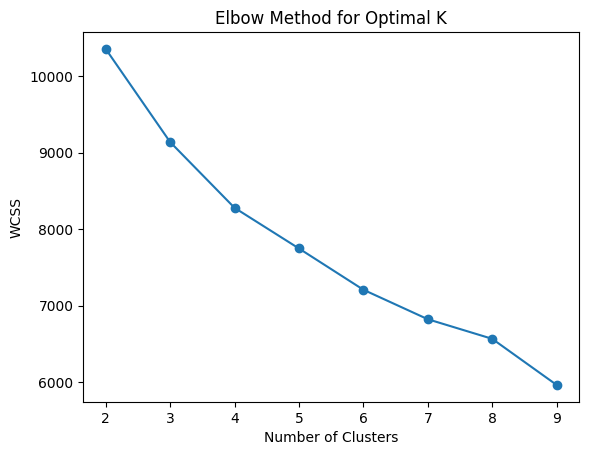

In [32]:
plt.plot(range(2,10),wcss,marker = "o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt. show()

In [35]:
#K=6
kmeans = KMeans(n_clusters = 6)
df["Cluster"] = kmeans.fit_predict(X_scaled)
cluster_summary = df.groupby("Cluster") [features].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,55.024145,35360.100410,106.979879,2.152918,3.303823,6.350101,75.772636
1,70.416667,73071.628763,1166.110000,4.413333,8.020000,2.556667,55.693333
2,60.067485,52035.404389,586.957055,6.751534,5.917178,6.751534,51.567485
3,46.232258,78955.980456,1318.867742,4.383871,8.432258,2.529032,52.487097
4,51.518868,33095.599620,93.703774,1.971698,3.141509,6.556604,25.001887
5,58.425993,66650.731884,1097.927798,7.765343,9.797834,5.509025,33.592058


In [36]:
df["Cluster"].value_counts()

Cluster
4    530
0    497
2    326
3    310
1    300
5    277
Name: count, dtype: int64

In [38]:
from sklearn.decomposition import PCA

pca = PCA(n_components= 2)
pca_data = pca.fit_transform(X_scaled)
df["PCA1"], df["PCA2"] = pca_data[:,0], pca_data[:,1]

pca_data

array([[ 1.09880249, -0.15244074],
       [-1.32956306,  0.35542855],
       [ 1.87353235, -0.99916071],
       ...,
       [ 1.16644005,  1.0552304 ],
       [ 1.88509355, -1.09859679],
       [-0.84207336, -0.06716606]], shape=(2240, 2))

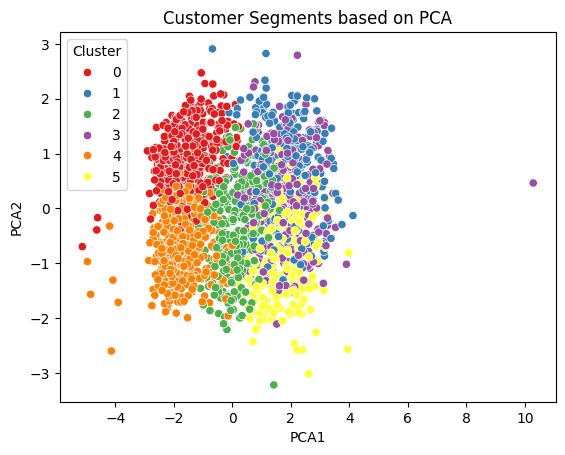

In [39]:
sns.scatterplot(x="PCA1", y="PCA2", hue = "Cluster", data = df, palette = "Set1")
plt.title("Customer Segments based on PCA")
plt.show()

In [41]:
cluster_summary = df.groupby("Cluster")[features].mean()
cluster_summary

,Age,Income,Total_Spending,NumWebPurchases,NumStorePurchases,NumWebVisitsMonth,Recency
Cluster,,,,,,,
0,55.024145,35360.100410,106.979879,2.152918,3.303823,6.350101,75.772636
1,70.416667,73071.628763,1166.110000,4.413333,8.020000,2.556667,55.693333
2,60.067485,52035.404389,586.957055,6.751534,5.917178,6.751534,51.567485
3,46.232258,78955.980456,1318.867742,4.383871,8.432258,2.529032,52.487097
4,51.518868,33095.599620,93.703774,1.971698,3.141509,6.556604,25.001887
5,58.425993,66650.731884,1097.927798,7.765343,9.797834,5.509025,33.592058


In [43]:
import joblib

#save model and scaler
joblib. dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']